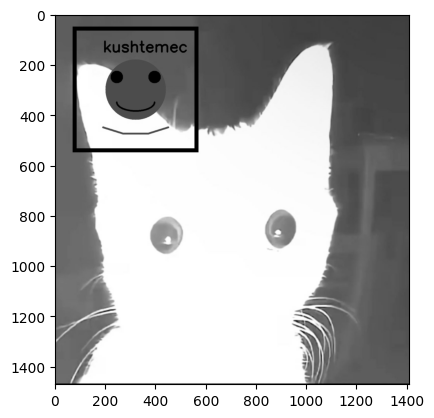

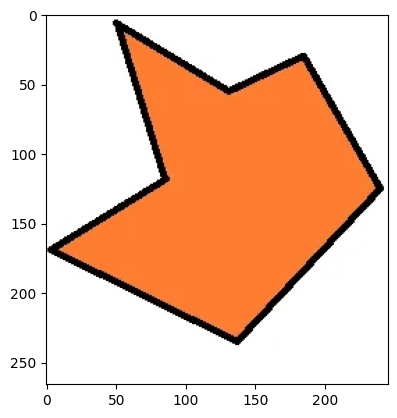

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('data_img/kushtemec.jpg')
polygon = cv2.imread('data_img/polygon.jpg')

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB))
plt.show()
plt.imshow(cv2.cvtColor(polygon, cv2.COLOR_BGR2RGB))
plt.show()

220531.5 1877.5563489198685 {'m00': 220531.5, 'm10': 70477219.5, 'm01': 66161145.166666664, 'm20': 26569794147.25, 'm11': 21151061875.291664, 'm02': 23906949798.916664, 'm30': 11077537577876.852, 'm21': 7976058059070.85, 'm12': 7645609222401.616, 'm03': 9607025943583.55, 'mu20': 4046760165.93132, 'mu11': 7354285.752162933, 'mu02': 4058097685.8863716, 'mu30': -127169072.90429688, 'mu21': 215030537.0588379, 'mu12': 1039242656.2167969, 'mu03': -163760976.671875, 'nu20': 0.08320821461129256, 'nu11': 0.00015121651940989527, 'nu02': 0.08344133314436546, 'nu30': -5.568073078658432e-06, 'nu21': 9.415070167161092e-06, 'nu12': 4.550303720959741e-05, 'nu03': -7.170242455315321e-06}


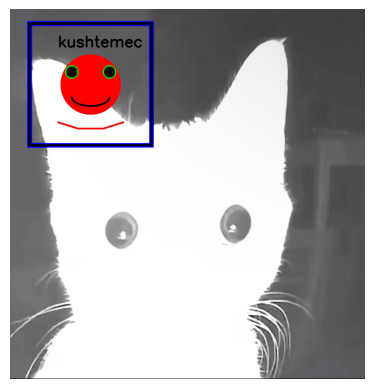

In [6]:
gray = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (3,3), 0)
# Бинаризация изображения: все пиксели со значением >40 становятся белыми (255), остальные - черными (0)
# THRESH_BINARY_INV инвертирует результат: фон становится белым, объекты - черными
_, binary = cv2.threshold(gray, 40, 255, cv2.THRESH_BINARY_INV)

# Размытие по гауссу, уменьшение шумов
# Размер ядра 3x3, sigma=0
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
# Морфологическая обработка: сначала закрытие (удаляет темные дыры внутри объектов),
# затем открытие (удаляет мелкий шум и выбросы)
binary = cv2.morphologyEx(cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel), cv2.MORPH_OPEN, kernel)

# Находим контуры на бинарном изображении
# RETR_LIST - извлекаем все контуры без иерархии, CHAIN_APPROX_SIMPLE - сжимаем горизонтальные/вертикальные сегменты
contours, _ = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
result = img.copy()
rect_area = rect_perimeter = None

# Проход по всем контурам
for cnt in contours:
    # Вычисление площадей контуром
    area = cv2.contourArea(cnt)
    # Маленькие контуры пропускаются(по пикселям)
    if area < 100: continue
    
    # Вычисляем периметр контура (замкнутая кривая)
    peri = cv2.arcLength(cnt, True)
    # Аппроксимируем контур многоугольником с точностью 2% от периметра
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    
    # Если у многоугольника 4 вершины - это прямоугольник
    if len(approx) == 4:
        # Рисуем прямоугольник толщиной 3 пикселя
        cv2.drawContours(result, [cnt], -1, (255, 0, 0), 3)
        # Сохраняем площадь и периметр первого контура
        if rect_area is None:
            
            rect_area, rect_perimeter = area, peri
            # Вычисляем моменты контура
            M = cv2.moments(cnt)
    else:
        # Вычисляем циркулярность, чем ближе к 1, тем ближе к кругу
        circularity = 4 * np.pi * area / (peri * peri)
        if circularity > 0.7:
            # Зарисовка круга
            cv2.drawContours(result, [cnt], -1, (0, 255, 0), 3)

print(rect_area,rect_perimeter,M)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

C:\Users\reino\AppData\Local\Temp\ipykernel_29752\1328950539.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lefty = int((-xp * vy / vx) + yp)
C:\Users\reino\AppData\Local\Temp\ipykernel_29752\1328950539.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  righty = int(((cols - xp) * vy / vx) + yp)


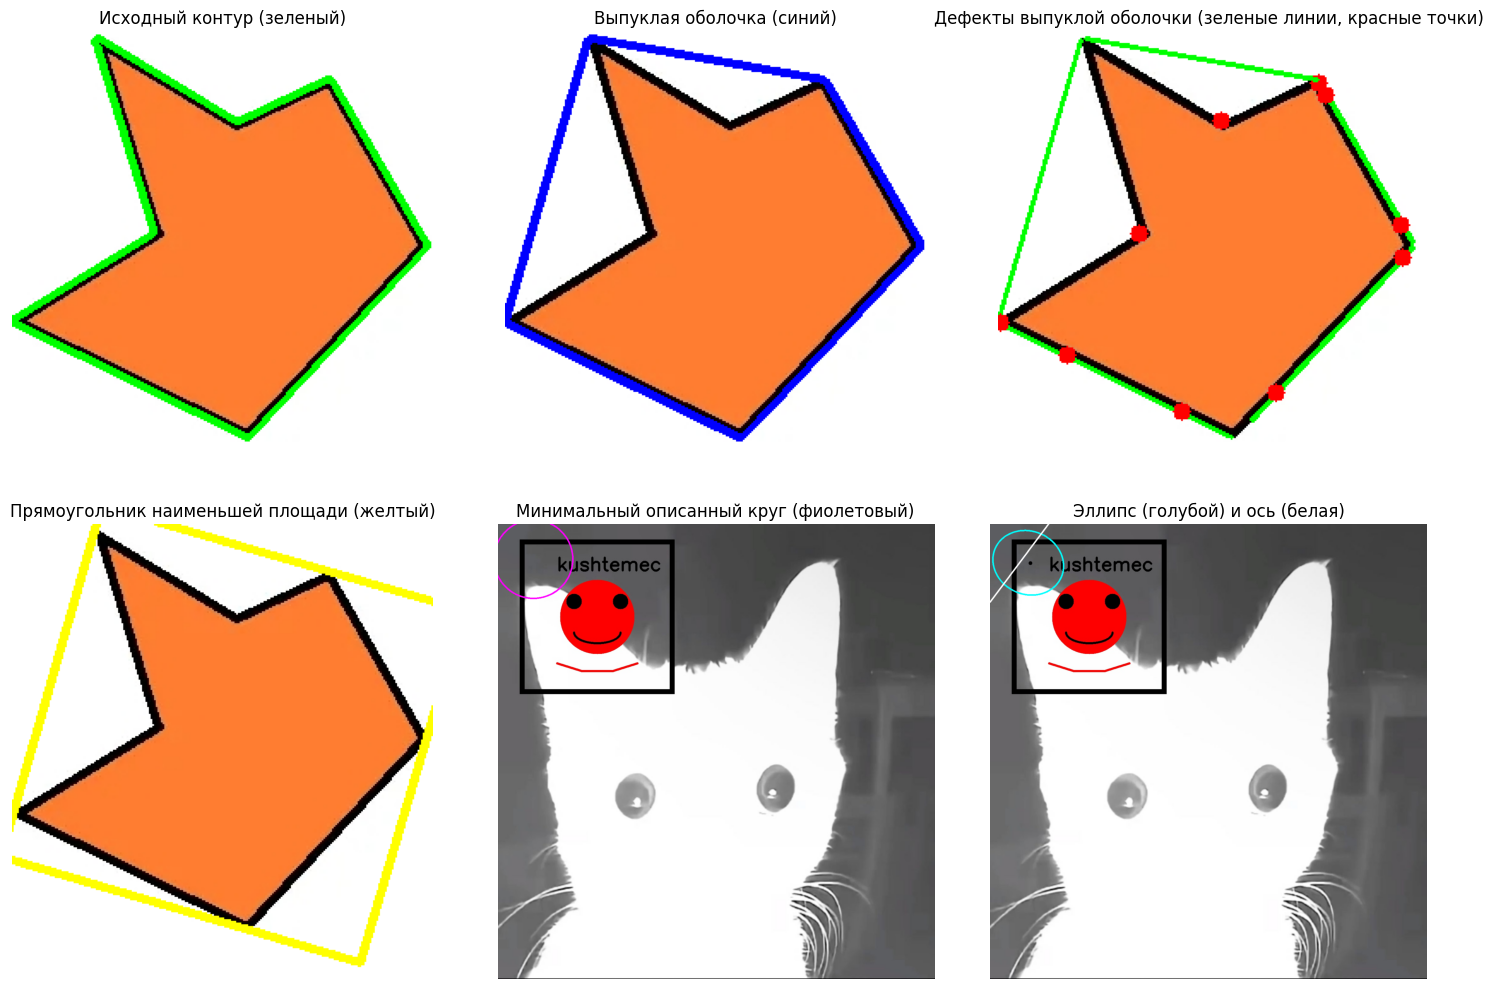

In [7]:
def show_images(images, titles, cols=3):
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()
    
    for i, (img, title) in enumerate(zip(images, titles)):
        axes[i].imshow(img)
        axes[i].set_title(title)
        axes[i].axis('off')
    
    for j in range(len(images), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Конвертируем исходное изображение в оттенки серого для бинаризации
gray = cv2.cvtColor(polygon, cv2.COLOR_BGR2GRAY)

# Бинаризация методом Оцу (Otsu) - автоматический порог
# THRESH_BINARY_INV: инвертируем (фон - белый, объект - черный)
# THRESH_OTSU: вычисляем оптимальный порог на основе гистограммы
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Создаем ядро 3x3 из единиц для морфологических операций
kernel = np.ones((3,3), np.uint8)
# Морфологическое закрытие: сначала дилатация (расширение), затем эрозия (сужение)
# Закрытие заполняет маленькие дыры внутри объекта и сглаживает границы
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# Находим контуры на бинарном изображении
# RETR_EXTERNAL: извлекаем только внешние контуры (игнорируем внутренние дыры)
# CHAIN_APPROX_SIMPLE: сжимаем сегменты (храним только конечные точки)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Выбираем самый большой контур по площади
cnt = max(contours, key=cv2.contourArea)

# Находим выпуклую оболочку контура (минимальный выпуклый многоугольник)
# returnPoints=True: возвращаем координаты точек
hull_points = cv2.convexHull(cnt, returnPoints=True)
# returnPoints=False: возвращаем индексы точек в исходном контуре
hull_indices = cv2.convexHull(cnt, returnPoints=False)

# Находим дефекты выпуклости (области, где контур вогнут внутрь оболочки)
defects = cv2.convexityDefects(cnt, hull_indices)

# Находим повернутый прямоугольник минимальной площади, охватывающий контур
# Возвращает (центр, размеры, угол поворота)
rect = cv2.minAreaRect(cnt)
# Получаем 4 угловые точки прямоугольника (формат float32)
box = cv2.boxPoints(rect)
box = np.int32(box) # Преобразуем в целые числа для рисования

# Находим минимальный круг, охватывающий все точки контура
(x, y), radius = cv2.minEnclosingCircle(cnt)
center = (int(x), int(y)) # Центр круга (целые пиксели)
radius = int(radius) # Радиус

# Аппроксимируем контур эллипсом (методом наименьших квадратов)
ellipse = cv2.fitEllipse(cnt) # Возвращает (центр, оси, угол поворота)

# Вычисляем моменты контура для нахождения центра масс
M = cv2.moments(cnt)
# Центр масс (центроид) - отношения моментов первого порядка к нулевому моменту
cx = int(M['m10'] / M['m00']) # Координата X центра масс
cy = int(M['m01'] / M['m00']) # Координата Y центра масс

# Аппроксимируем контур прямой линией (методом наименьших квадратов)
# DIST_L2: евклидово расстояние, параметры точности 0.01
[vx, vy, xp, yp] = cv2.fitLine(cnt, cv2.DIST_L2, 0, 0.01, 0.01)

# Вычисляем точки для отрисовки линии от левого до правого края изображения
rows, cols = polygon.shape[:2]
# Вычисляем координаты Y на левом и правом краях изображения
# Формула: (y - yp) / (x - xp) = vy / vx
lefty = int((-xp * vy / vx) + yp)
righty = int(((cols - xp) * vy / vx) + yp)


img_contour = polygon.copy()
cv2.drawContours(img_contour, [cnt], -1, (0, 255, 0), 3)

# 2. Выпуклая оболочка
img_hull = polygon.copy()
cv2.drawContours(img_hull, [hull_points], -1, (255, 0, 0), 3)

# 3. Дефекты
img_defects = polygon.copy()
if defects is not None:
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i, 0]
        start = tuple(cnt[s][0])
        end = tuple(cnt[e][0])
        far = tuple(cnt[f][0])
        cv2.line(img_defects, start, end, (0, 255, 0), 2)
        cv2.circle(img_defects, far, 5, (0, 0, 255), -1)

# 4. Прямоугольник наименьшей площади
img_rect = polygon.copy()
cv2.drawContours(img_rect, [box], 0, (0, 255, 255), 3)

# 5. Круг
img_circle = img.copy()
cv2.circle(img_circle, center, radius, (255, 0, 255), 3)

# 6. Эллипс и ось
img_ellipse = img.copy()
cv2.ellipse(img_ellipse, ellipse, (255, 255, 0), 3)
cv2.line(img_ellipse, (cols-1, righty), (0, lefty), (255, 255, 255), 3)
cv2.circle(img_ellipse, (cx, cy), 6, (0, 0, 0), -1)

# Конвертируем все в RGB для matplotlib
images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in [img_contour, img_hull, img_defects, img_rect, img_circle, img_ellipse]]
titles = [
    "Исходный контур (зеленый)",
    "Выпуклая оболочка (синий)",
    "Дефекты выпуклой оболочки (зеленые линии, красные точки)",
    "Прямоугольник наименьшей площади (желтый)",
    "Минимальный описанный круг (фиолетовый)",
    "Эллипс (голубой) и ось (белая)"
]

show_images(images, titles, cols=3)

Найден наибольший контур. Площадь: 110,610 px


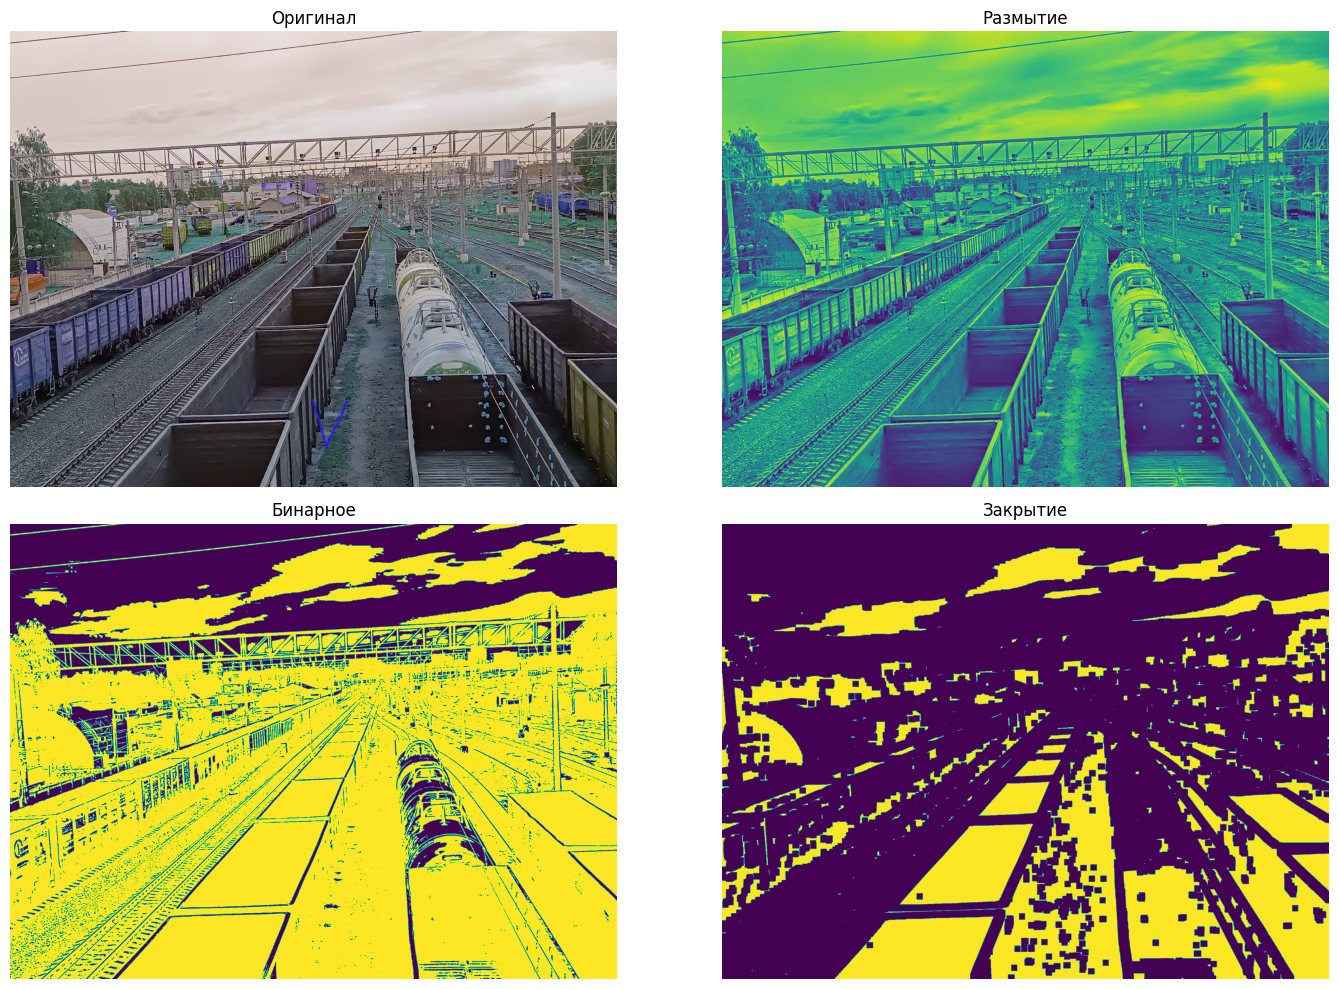

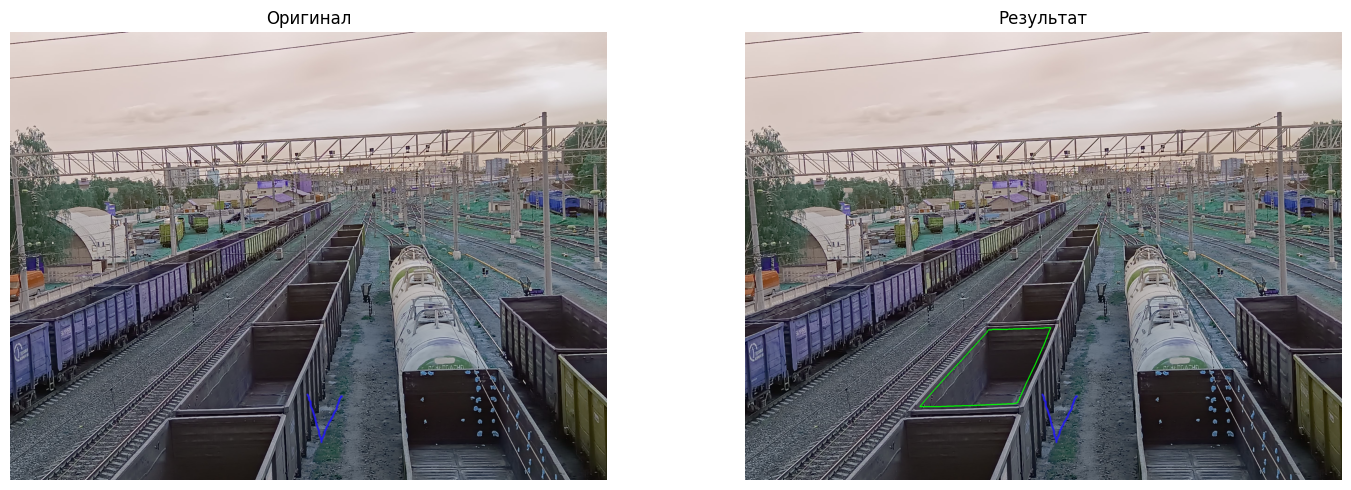

In [10]:
img = cv2.imread('data_img/railway_carriage.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Применяем CLAHE (Contrast Limited Adaptive Histogram Equalization)
# clipLimit=2.0: ограничение контраста (предотвращает усиление шума)
# tileGridSize=(10,10): размер сетки для адаптивной нормализации (10x10 пикселей)
# CLAHE улучшает локальный контраст, что особенно полезно для изображений с неравномерным освещением
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(10, 10)).apply(gray)

# Применяем размытие по Гауссу для уменьшения шума
# Ядро 5x5, sigma=0 (рассчитывается автоматически)
blurred = cv2.GaussianBlur(clahe, (5, 5), 0)

# Бинаризация: преобразуем изображение в черно-белое
# Порог 190: пиксели со значением >190 становятся белыми, иначе черными
# THRESH_BINARY_INV: инвертируем результат (объекты становятся черными, фон - белым)
_, binary = cv2.threshold(blurred, 190, 255, cv2.THRESH_BINARY_INV)

# Создаем прямоугольное структурирующее ядро 9x9 для морфологических операций
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
# Эрозия (сужение): удаляем мелкий шум и отделяем несвязанные объекты
# iterations=3: применяем эрозию 3 раза подряд для усиления эффекта
eroded = cv2.erode(binary, kernel, iterations=3)

# Закрытие: сначала дилатация (расширение), затем эрозия
# Закрытие заполняет небольшие дыры и соединяет близкие объекты
closed = cv2.morphologyEx(eroded, cv2.MORPH_CLOSE, kernel, iterations=1)

# Находим контуры на обработанном бинарном изображении
# RETR_EXTERNAL: извлекаем только внешние контуры (без внутренних отверстий)
# CHAIN_APPROX_SIMPLE: сжимаем контуры, сохраняя только ключевые точки
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest_cnt = None # Самый большой найденный прямоугольный контур
max_area = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 5000: # Меньше 5000 пикселей
        continue
    
    # Вычисляем периметр контура
    peri = cv2.arcLength(cnt, True)

    # Аппроксимируем контур многоугольником с точностью 2% от периметра
    # Чем меньше точность, тем более детальная аппроксимация
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    
    # Проверка на 4 вершины и прямоугольность
    if len(approx) == 4:
        approx_area = cv2.contourArea(approx)

        # Если отношение между 0.85 и 1.15 (допуск 15% в обе стороны)
        # Это значит, что контур хорошо аппроксимируется прямоугольником
        if approx_area > 0 and 0.85 < area / approx_area < 1.15:
            if area > max_area:
                max_area = area
                largest_cnt = cnt

# 3. Визуализация результата
result_img = img.copy()
cv2.drawContours(result_img, [largest_cnt], -1, (0, 255, 0), 3)
print(f"Найден наибольший контур. Площадь: {max_area:,.0f} px")

show_images([img, blurred, binary, closed],["Оригинал", "Размытие", "Бинарное", "Закрытие"], cols=2)
show_images([img, result_img], ["Оригинал", "Результат"], cols=2)